# Climate Coding Challenge

Climate change is impacting the way people live around the world



## Set up

To get started on this notebook, you’ll need to restore any variables
from previous notebooks to your workspace. To save time and memory, make
sure to specify which variables you want to load.

In [1]:
%store -r

You will also need to import any libraries you are using in this
notebook, since they won’t carry over from the previous notebook:

In [2]:
### import libraries

import earthpy ### manage local data
import holoviews as hv ### save interactive plots
import hvplot.pandas ### make interactive plots
import hvplot ### plotting
import pandas as pd ### work with tabular data in data frames

## Step 5: Quantify how fast the climate is changing with a trend line

Global climate change causes different effects in different places when
we zoom in to a local area. However, you probably noticed when you
looked at mean annual temperatures over time that they were rising. We
can use a technique called **Linear Ordinary Least Squares (OLS)
Regression** to determine how quickly temperatures are rising on
average.

Before we get started, it’s important to consider that OLS regression is
not always the right technique, because it makes some important
assumptions about our data:

**Random error**  
Variation in temperature can be caused by many things beyond global
climate change. For example, temperatures often vary with patterns of
ocean surface temperatures (*teleconnections*), the most famous of which
are El Niño and La Niña. By using a linear OLS regression, we’re
assuming that all the variation in temperature except for climate change
is random.

**Normally distributed data**  
If you have taken a statistics class, you probably learned a lot about
the normal, or Gaussian distribution. For right now, what you need to
know is that OLS regression is useful for identifying trends in average
temperature, but wouldn’t be appropriate for looking at trends in daily
precipitation (because most days have zero precipitation), or at maximum
or minimum annual temperatures (because these are extreme values, and
the normal distribution tends to underestimate the likelihood of large
events).

**Linearity**  
We’re assuming that temperatures are increasing or decreasing at a
constant rate over time. We wouldn’t be able to look at rates that
change over time. For example, many locations in the Arctic remained the
same temperature for much longer than the rest of the world, because ice
melt was absorbing all the extra heat. Linear OLS regression wouldn’t be
able to identify when the temperature rise began on its own.

**Stationarity**  
We’re assuming that variation in temperature caused by things *other*
than global climate change (e.g. the random error) behaves the same over
time. For example, the linear OLS regression can’t take increased
variability from year to year into account, which is a common effect of
climate change. We often see “global weirding”, or more extreme head
*and* cold, in addition to overall increases. You can observe this most
easily by looking at your daily data again. Does it seem to be fanning
in or out over time?

It’s pretty rare to encounter a perfect statistical model where all the
assumptions are met, but you want to be on the lookout for serious
discrepancies, especially when making predictions. For example,
[ignoring assumptions about Gaussian error arguably led to the 2008
financial crash](https://www.wired.com/2009/02/wp-quant/).

### Reflect and Respond #3: Is linear OLS regression right for your data?
Take a look at your data. In the cell below, write a few sentences about ways your data does and does not meet the linear OLS regression assumptions.

Random error - As noted above, it is likely that not all of the error in the data is truly random, but there are also no clear patterns suggesting a significantly non-random component. 

Normal distribution - Since the data is averaged and the data set spans a large number of years, the assumption of normal distribution is a reasonable one. 

Linearity - The plot of the annual mean data shows a general trend of increasing temperature over time. While there does appear to be some variation in slope and there are definitely some outliers and discontinuities, the genearal trend is more linear than anything else. 

Stationarity - The plot of daily data does not have a "horn shape" that would characterize increasing or decreasing variability, so it is acceptable to assume stationarity. 

The following cell contains package imports that you will need to calculate and plot an OLS Linear trend line. Make sure to run the cell before moving on, and if you have any additional packages you would like to use, add them here later on:

In [3]:
### advanced options on matplotlib/seaborn/pandas plots
import matplotlib.pyplot as plt
### common statistical plots for tabular data
import seaborn as sns
### fit an OLS linear regression
from sklearn.linear_model import LinearRegression

<link rel="stylesheet" type="text/css" href="./assets/styles.css"><div class="callout callout-style-default callout-titled callout-task"><div class="callout-header"><div class="callout-icon-container"><i class="callout-icon"></i></div><div class="callout-title-container flex-fill">Try running a regression</div></div><div class="callout-body-container callout-body"><ol type="1">
<li>Adapt the sample code below to fit your variable names.</li>
<li>Check out your previous plot. Does it make sense to include all the
data when calculating a trend line? Be sure to select out data that
meets the OLS assumptions.</li>
</ol></div></div>

In [10]:
ann_temp_df.head()

,temp_f,temp_c
DATE,,
1901-01-01,52.917355,11.620753
1902-01-01,52.958678,11.643710
1903-01-01,52.142857,11.190476
1904-01-01,53.424658,11.902588
1905-01-01,51.274238,10.707910


In [33]:
### verify data set does not have any NaN values
print(ann_temp_df.isna().sum())

### remove na data from data frame
ann_temp_df = ann_temp_df.dropna()

### verify data set does not have any NaN values
print(ann_temp_df.isna().sum())

### reduce data set to only celcius and date 
ann_temp_c_df = ann_temp_df[['temp_c']]

### filter data to avoid data gap and use only 1941-2023
clean_ann_temp_c_df = ann_temp_c_df.loc['1941':'2023']

clean_ann_temp_c_df.head()

### create two subset groups of years that show different slopes
### 1941-1980
early_ann_temp_df = clean_ann_temp_c_df.loc['1941':'1980']
### 1980-2023
late_ann_temp_df = clean_ann_temp_c_df.loc['1980':'2023']


temp_f    0
temp_c    0
dtype: int64
temp_f    0
temp_c    0
dtype: int64


In [34]:
### fit an OLS Linear Regression to the data

### define independent variable
### reshape 'year' to be a 2D array for scikit-learn
x = clean_ann_temp_c_df.index.year.values.reshape(-1, 1)

### define dependent variable
y = clean_ann_temp_c_df.temp_c

### make linear regression model
model = LinearRegression()

### fit the model on the data
model.fit(x, y)

### calculate and print metrics
print(f'Slope: {model.coef_[0]} degrees per year')

Slope: 0.04397975861613436 degrees per year


In [35]:
### rerun regression for the two subset year groups

x1 = early_ann_temp_df.index.year.values.reshape(-1, 1)
y1 = early_ann_temp_df.temp_c

x2 = late_ann_temp_df.index.year.values.reshape(-1, 1)
y2 = late_ann_temp_df.temp_c

### fit the model on the data
mod1 = model.fit(x1, y1)

### calculate and print metrics
print(f'Early Slope: {mod1.coef_[0]} degrees per year')

### fit the model on the data
mod2 = model.fit(x2, y2)

### calculate and print metrics
print(f'Late Slope: {mod2.coef_[0]} degrees per year')


Early Slope: 0.1545090661897956 degrees per year
Late Slope: 0.049123576751099816 degrees per year


### Step 5B: Plot your trend line

Trend lines are often used to help your audience understand and process
a time-series plot. In this case, we’ve chosen mean temperature values
rather than extremes, so we think OLS is an appropriate model to use to
show a trend.

> **Is it ok to plot a trend line even if OLS isn’t an appropriate
> model?**
>
> This is a tricky issue. When it comes to a trend line, choosing a
> model that is technically more appropriate may require much more
> complex code without resulting in a noticeably different trend line.
>
> We think an OLS trend line is an ok visual tool to indicate the
> approximate direction and size of a trend. If you are showing standard
> error, making predictions or inferences based on your model, or
> calculating probabilities (p-values) based on your model, or making
> statements about the statistical significance of a trend, we’d suggest
> reconsidering your choice of model.

<link rel="stylesheet" type="text/css" href="./assets/styles.css"><div class="callout callout-style-default callout-titled callout-task"><div class="callout-header"><div class="callout-icon-container"><i class="callout-icon"></i></div><div class="callout-title-container flex-fill">Try it:</div></div><div class="callout-body-container callout-body"><ol type="1">
<li>Add values for x (year) and y (temperature) to plot a regression
plot. You will have to select out the year from the index values, just
like you probably did when fitting your linear model above!</li>
<li>Label the axes of your plot with the <code>title</code>,
<code>xlabel</code>, and <code>ylabel</code> parameters. You can see how
to add the degree symbol in the example below. Make sure your labels
match what you’re plotting!</li>
<li>Can you figure out how to customize the colors and line style on your plot? Check out the <code>seaborn</code> <a
href="https://seaborn.pydata.org/">documentation</a> for ideas.</li>
</ol></div></div>

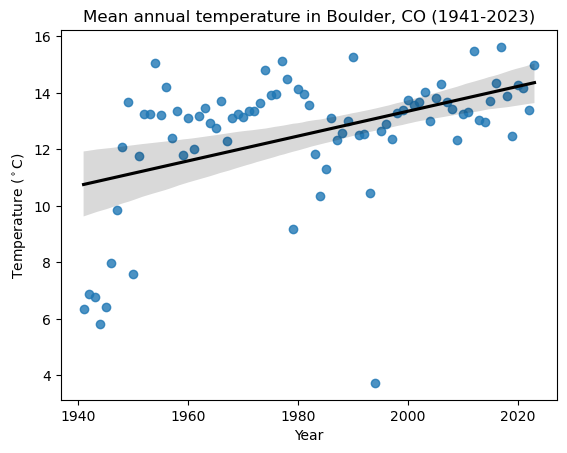

In [25]:
### plot data
ax = sns.regplot(
    x = clean_ann_temp_c_df.index.year, 
    y = clean_ann_temp_c_df.temp_c,

    line_kws={"color": "black"} # trendline color
)


### make labels
ax.set(
    title = 'Mean annual temperature in Boulder, CO (1941-2023)',
    xlabel = 'Year',
    ylabel = 'Temperature ($^\circ$C)'
)

### save your plot
plt.savefig('/workspaces/01-climate-fall-template/mean_ann_temp_w_trend_boulder.jpeg')

### plot it
plt.show()

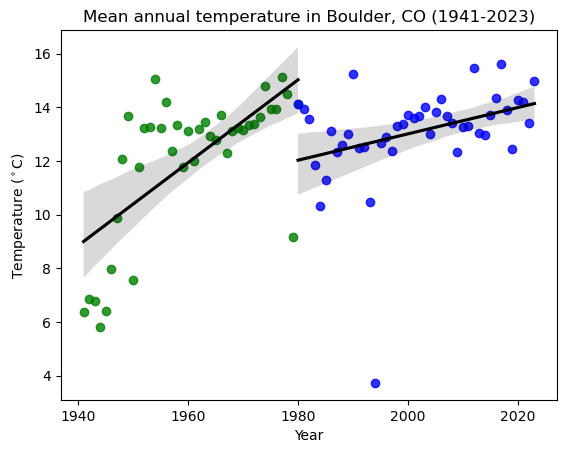

In [39]:
### plot data
ax = sns.regplot(
    x = early_ann_temp_df.index.year, 
    y = early_ann_temp_df.temp_c,
    label = "1941-1980",

    color = 'green', # points color

    line_kws={"color": "black"} # trendline color
)
ax = sns.regplot(
    x = late_ann_temp_df.index.year, 
    y = late_ann_temp_df.temp_c,
    label = "1980-2023",

    color = 'blue', # points color

    line_kws={"color": "black"} # trendline color
)


### make labels
ax.set(
    title = 'Mean annual temperature in Boulder, CO (1941-2023)',
    xlabel = 'Year',
    ylabel = 'Temperature ($^\circ$C)'
)

### save your plot
plt.savefig('/workspaces/01-climate-fall-template/mean_ann_temp_w_trend_boulder.jpeg')

### plot it
plt.show()

### Reflect and Respond #4: Interpret the trend
1.  Create a new Markdown cell below this one.
2. Write a plot headline. Your headline should **interpret** your plot, unlike a caption which neutrally
describes the image.
3. Is the climate changing? How much? Report the slope of your trend line.

Boulder, CO mean annual temperature has been increasing at a rate of approximately 0.05 degrees a year. This rate was calculated over a period from 1941 to 2023. Looking at the data as two segments, it is notable that the temperature increase rate from 1941 to 1980 is approximately 0.15 degrees per year, almost three times the temperature increase rate from 1980 to 2023, 0.049 degrees per year, which is also the rate calculated for the whole period. This shows that the recent rate has slowed from what it was during the first part of the record period. 